# pmai-model-context

# Introduction
This notebook uses Hugging Face to train models for automatic image description (image captioning). With libraries such as Transformers, Datasets, and Accelerate

## **Estandar**

1. Codigo se desarrollara en ingles
2. Los prompts en español
3. Usar visualizadores

In [374]:
import importlib
import utils.cache as cache_utils
import utils.model as model_utils
import utils.context as context_utils


#___________________________________________________________________

from utils.decoder import base64_to_image
from utils.decoder import base64_to_image_resized
from utils.local_object import GlobalObjectForContext, context_info
from utils.local_object import GlobalObjectForContext


In [375]:
cache_utils = importlib.reload(cache_utils)
model_utils = importlib.reload(model_utils)
context_utils = importlib.reload(context_utils)


import_Blip_model = model_utils.import_Blip_model
get_quantized_blip_model = model_utils.get_quantized_blip_model
generate_context = context_utils.generate_context



In [376]:
import torch
import time
import os

torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except Exception:
    pass

#### 5 ) **Image Decoding**

In [377]:
processor, blip_model = import_Blip_model()

In [378]:
model_quantized = get_quantized_blip_model(
    blip_model,
    model_name=model_utils.MODEL_ID,
    engine="qnnpack",
    dtype=torch.qint8,
)

In [379]:
from pathlib import Path

image_path = Path("objetos/6.txt")
processor.image_processor.do_resize = True
processor.image_processor.do_center_crop = False
processor.image_processor.size = {"height": 385, "width": 385}

variablexenbase = image_path.read_text(encoding="utf-8").strip()
pil_image = base64_to_image(variablexenbase)

contexto, prompt = generate_context(pil_image, processor, model_quantized)

print(f"contexto: {contexto}")

contexto: a photo of a mascot wearing a red t - shirt and standing in front of an exhibit booth with a sign that reads sebre


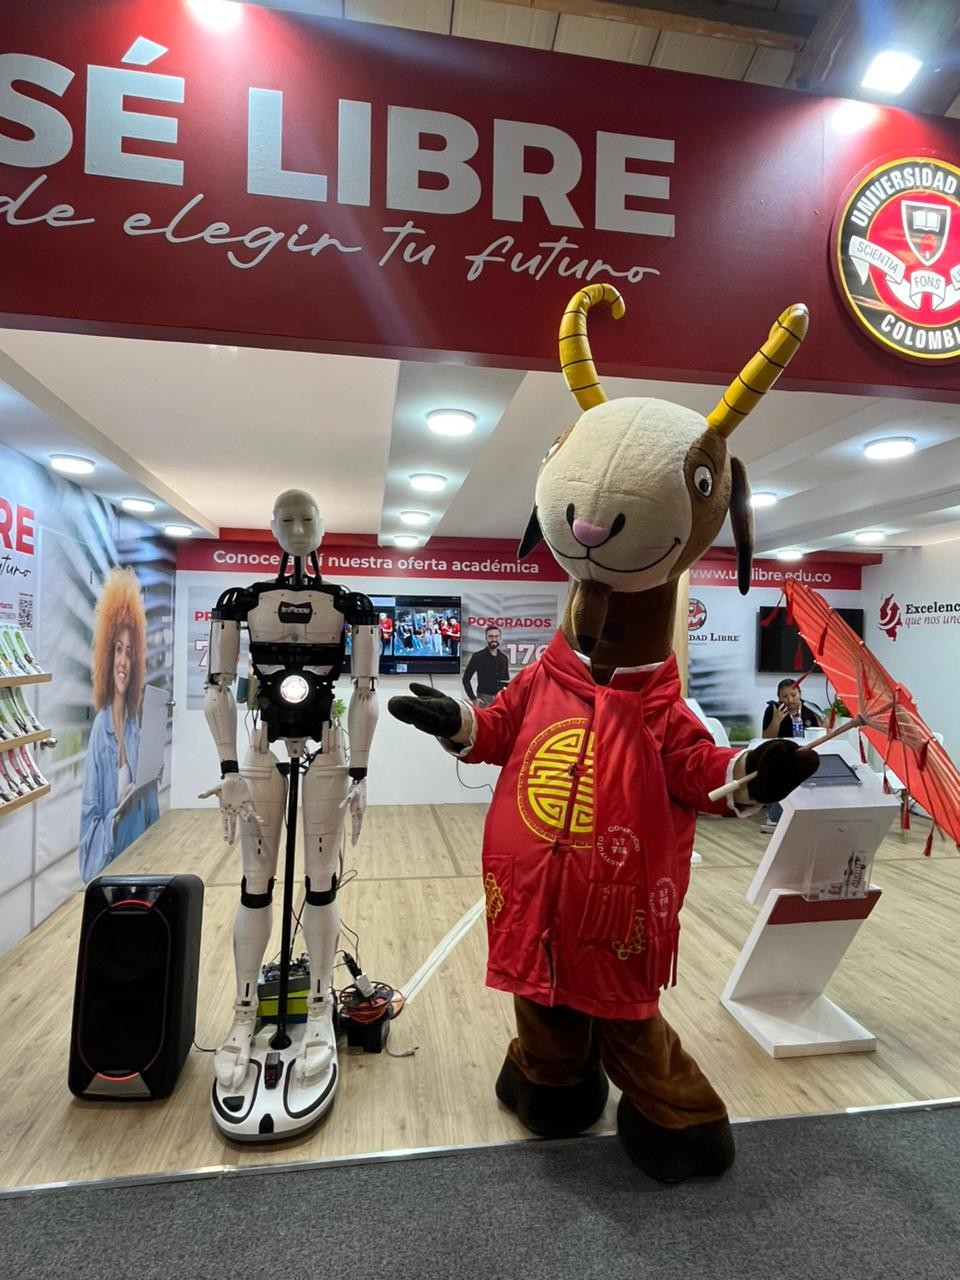

In [380]:
pil_image